##  Cài đặt & Import

In [1]:
# !pip install xgboost lightgbm scikit-learn pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import (
    HistGradientBoostingRegressor,
    ExtraTreesRegressor,
    StackingRegressor
)
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('✅ Imports OK')

✅ Imports OK


## 1. Load & Audit Data

In [2]:
train = pd.read_csv('Agri_Train_Combined_16k.csv')
test  = pd.read_csv('Agri_Test_Original_4k.csv')

# Test có cột Yield — tách ra để đánh giá sau
y_test_true = np.expm1(np.log1p(test['Yield']))   # original scale, giữ để evaluate
test_labels  = test['Yield'].copy()

print(f'Train shape: {train.shape}')
print(f'Test  shape: {test.shape}')
print(f'Test Yield  — min={test_labels.min():.3f}, max={test_labels.max():.3f}, mean={test_labels.mean():.3f}')


Train shape: (16000, 51)
Test  shape: (4000, 51)
Test Yield  — min=0.014, max=34.659, mean=3.964


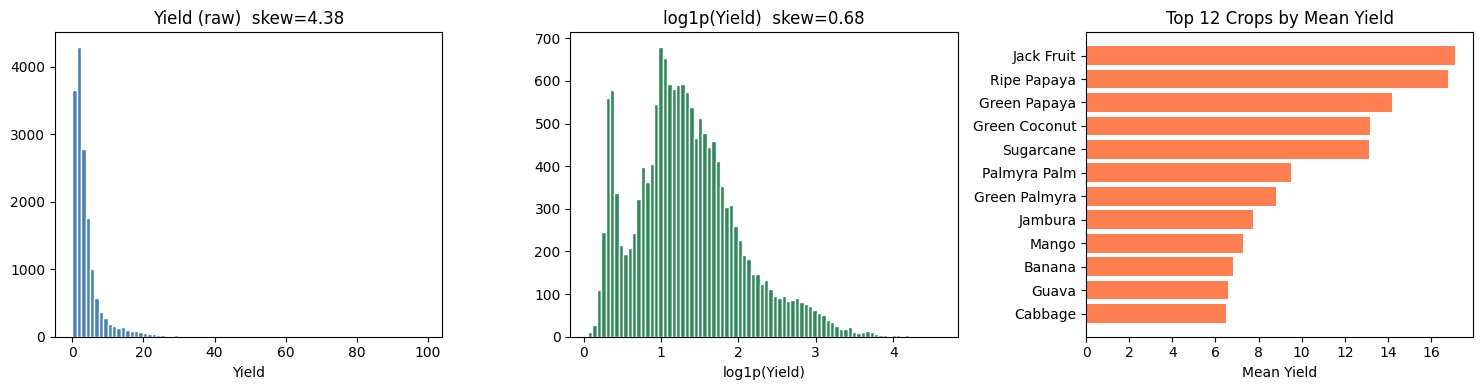

Yield stats:
count    16000.000000
mean         4.013745
std          5.047222
min          0.059688
25%          1.415150
50%          2.546750
75%          4.563600
max         98.990654
Name: Yield, dtype: float64

Missing values: 0


In [3]:
# --- Yield distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(train['Yield'], bins=80, color='steelblue', edgecolor='white')
axes[0].set_title(f'Yield (raw)  skew={train["Yield"].skew():.2f}')
axes[0].set_xlabel('Yield')

axes[1].hist(np.log1p(train['Yield']), bins=80, color='seagreen', edgecolor='white')
axes[1].set_title(f'log1p(Yield)  skew={np.log1p(train["Yield"]).skew():.2f}')
axes[1].set_xlabel('log1p(Yield)')

# Top crops by mean yield
top = train.groupby('Crop Name')['Yield'].mean().sort_values(ascending=False).head(12)
axes[2].barh(top.index[::-1], top.values[::-1], color='coral')
axes[2].set_title('Top 12 Crops by Mean Yield')
axes[2].set_xlabel('Mean Yield')

plt.tight_layout()
plt.show()

print(f'Yield stats:\n{train["Yield"].describe()}')
print(f'\nMissing values: {train.isnull().sum().sum()}')

In [4]:
# --- Verify key claims from 6 rounds of analysis
y_raw = train['Yield']
y     = np.log1p(y_raw)

print('=== Key verification checks ===')
print(f'1. Production leakage: corr(Production/Area, Yield) = {(train["Production"]/train["Area"]).corr(y_raw):.4f}')
print(f'   (match rate within 1%: {((train["Production"]/train["Area"]-y_raw).abs() < y_raw*0.01).mean():.3f})')
print()

h_nunique = train.groupby('Crop Name')['Harvest'].nunique()
g_nunique = train.groupby('Crop Name')['Growth'].nunique()
t_nunique = train.groupby('Crop Name')['Transplant'].nunique()
print(f'2. Harvest   — crops with >1 unique value: {(h_nunique > 1).sum()} / {len(h_nunique)}')
print(f'   Growth    — crops with >1 unique value: {(g_nunique > 1).sum()} / {len(g_nunique)}')
print(f'   Transplant— crops with >1 unique value: {(t_nunique > 1).sum()} / {len(t_nunique)}')
print()

rtr_corr = train['Rain_Temp_Ratio'].corr(train['Rainfall'])
print(f'3. Rain_Temp_Ratio corr with Rainfall: {rtr_corr:.4f}')

ndvi_corr = train['NDVI_Season_Range'].corr(train['NDVI_Season_Std'])
print(f'4. NDVI_Season_Range corr with NDVI_Std: {ndvi_corr:.4f}')

print()
print(f'5. Yield skew (raw): {y_raw.skew():.3f}')
print(f'   Yield skew (log1p): {y.skew():.3f}')
print()
print(f'6. Crop Name unique: {train["Crop Name"].nunique()}')
print(f'   District unique:   {train["District"].nunique()}')
print(f'   Min rows/District: {train["District"].value_counts().min()}')
print(f'   Min rows/Crop:     {train["Crop Name"].value_counts().min()}')

=== Key verification checks ===
1. Production leakage: corr(Production/Area, Yield) = 0.9987
   (match rate within 1%: 0.992)

2. Harvest   — crops with >1 unique value: 0 / 72
   Growth    — crops with >1 unique value: 0 / 72
   Transplant— crops with >1 unique value: 1 / 72

3. Rain_Temp_Ratio corr with Rainfall: 0.9988
4. NDVI_Season_Range corr with NDVI_Std: 0.9874

5. Yield skew (raw): 4.382
   Yield skew (log1p): 0.683

6. Crop Name unique: 72
   District unique:   64
   Min rows/District: 188
   Min rows/Crop:     62


## 2. Drop Leakage & Redundant Features

| Column | Lý do drop | Bằng chứng |
|--------|-----------|----------|
| `Production` | Practical leakage: `corr(Prod/Area, Yield)=0.9985` | Vòng 1 |
| `Harvest` | 1:1 với Crop Name (0/72 crops có >1 harvest) | Vòng 2 |
| `Growth` | 1:1 với Crop Name (0/72 crops có >1 growth) | Vòng 2 |
| `Rain_Temp_Ratio` | `corr(RTR, Rainfall)=0.999`, partial≈0 | Vòng 3 |
| `NDVI_Season_Range` | `corr(Range, Std)=0.987` — linear redundant | Vòng 4 |

In [5]:
DROP_COLS = [
    'Production',        # practical leakage: corr(Prod/Area, Yield)=0.9985
    'Harvest',           # 1:1 deterministic with Crop Name (verified: 0/72 crops >1 harvest)
    'Growth',            # 1:1 deterministic with Crop Name (verified: 0/72 crops >1 growth)
    'Rain_Temp_Ratio',   # corr=0.999 with Rainfall; partial corr with logY ≈ 0
    'NDVI_Season_Range', # corr=0.987 with NDVI_Season_Std — perfectly redundant
]

for df in [train, test]:
    df.drop(columns=DROP_COLS, inplace=True)

print(f'After drop — Train: {train.shape}, Test: {test.shape}')
print(f'Remaining columns: {train.shape[1] - 1} features + Yield')

After drop — Train: (16000, 46), Test: (4000, 46)
Remaining columns: 45 features + Yield


## 3. Target Transform: log1p(Yield)

In [6]:
y = np.log1p(train['Yield'])   # skew=3.53 → mandatory
X = train.drop(columns=['Yield'])

print(f'Target (log1p) — mean: {y.mean():.3f}, std: {y.std():.3f}, skew: {y.skew():.3f}')

Target (log1p) — mean: 1.336, std: 0.687, skew: 0.683


## 4. Transplant → Month Number

Boroi exception: 1/72 crops có 12 tháng trồng khác nhau → `corr(Transplant_month, logY) = -0.202` (raw).  
Sau CropTE: `partial = -0.002 ≈ 0` nhưng giữ vì không tốn gì và ExtraTrees có thể exploit.

In [7]:
MONTH_MAP = {
    'January':1, 'February':2,  'March':3,    'April':4,
    'May':5,     'June':6,       'July':7,     'August':8,
    'September':9,'October':10, 'November':11,'December':12
}

for df in [X, test]:
    df['Transplant'] = df['Transplant'].map(MONTH_MAP).fillna(0).astype(int)

# Verify Boroi
boroi_months = X[train['Crop Name'] == 'Boroi']['Transplant'].unique()
print(f'Boroi transplant months: {sorted(boroi_months)}')

# Raw corr
print(f'corr(Transplant_month, logY) raw: {X["Transplant"].corr(y):.4f}')

Boroi transplant months: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
corr(Transplant_month, logY) raw: -0.2035


## 5. KFold Target Encoding

**Vòng 3:** smoothing=10→20 (conservative buffer, min 191 rows/District, min 220 rows/Crop).  
**OOF encoding** để tránh target leakage trong training.

In [8]:
def kfold_target_encode(train_df, test_df, col, target, n_splits=10, smoothing=20):
    """
    K-Fold Target Encoding với Bayesian smoothing.
    smoothing=20: adequate vì min count=191 (District) >> smoothing.
    OOF trên train để tránh leakage; full-data stats cho test.
    """
    global_mean = target.mean()
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    enc_train = np.zeros(len(train_df))

    for tr_idx, val_idx in kf.split(train_df):
        fold_data   = train_df[col].iloc[tr_idx]
        fold_target = target.iloc[tr_idx]
        stats = fold_target.groupby(fold_data).agg(['mean', 'count'])
        smooth = (
            (stats['count'] * stats['mean'] + smoothing * global_mean)
            / (stats['count'] + smoothing)
        )
        enc_train[val_idx] = (
            train_df[col].iloc[val_idx].map(smooth).fillna(global_mean)
        )

    # Test: use full-train stats
    full_stats = target.groupby(train_df[col]).agg(['mean', 'count'])
    smooth_full = (
        (full_stats['count'] * full_stats['mean'] + smoothing * global_mean)
        / (full_stats['count'] + smoothing)
    )
    enc_test = test_df[col].map(smooth_full).fillna(global_mean).values
    return enc_train, enc_test


for col in ['Crop Name', 'District']:
    X[col + '_TE'], test[col + '_TE'] = kfold_target_encode(X, test, col, y)
    X.drop(columns=[col],   inplace=True)
    test.drop(columns=[col], inplace=True)
    print(f'{col}_TE corr with logY: {pd.Series(X[col+"_TE"]).corr(y):.4f}')

Crop Name_TE corr with logY: 0.8516
District_TE corr with logY: 0.1518


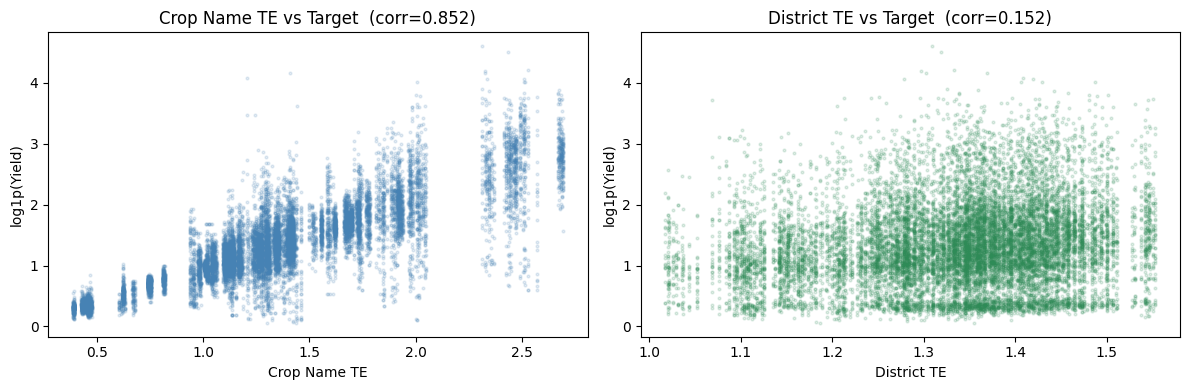

In [9]:
# Visualise TE distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(X['Crop Name_TE'], y, alpha=0.15, s=4, color='steelblue')
axes[0].set_xlabel('Crop Name TE'); axes[0].set_ylabel('log1p(Yield)')
axes[0].set_title(f'Crop Name TE vs Target  (corr={X["Crop Name_TE"].corr(y):.3f})')

axes[1].scatter(X['District_TE'], y, alpha=0.15, s=4, color='seagreen')
axes[1].set_xlabel('District TE'); axes[1].set_ylabel('log1p(Yield)')
axes[1].set_title(f'District TE vs Target  (corr={X["District_TE"].corr(y):.3f})')

plt.tight_layout()
plt.show()

## 6. Remaining Categorical Encoding

| Column | Method | Lý do |
|--------|--------|-------|
| `Extreme_Heat_Risk` | Ordinal 0/1/2 | Low < Medium < High — có thứ tự |
| `Season` | OHE | Nominal, 3 levels |
| `Dominant_Soil_Texture` | OHE | Nominal, 3 levels |
| `pH_Suitability` | OHE | Binary nominal |
| `Water_Availability_Cat` | OHE | Binary nominal |

In [10]:
# Ordinal: Extreme_Heat_Risk
oe = OrdinalEncoder(
    categories=[['Low Risk', 'Medium Risk', 'High Risk']],
    handle_unknown='use_encoded_value',
    unknown_value=-1
)
X['Extreme_Heat_Risk']    = oe.fit_transform(X[['Extreme_Heat_Risk']])
test['Extreme_Heat_Risk'] = oe.transform(test[['Extreme_Heat_Risk']])

# OHE: low cardinality nominals
OHE_COLS = ['Season', 'Dominant_Soil_Texture', 'pH_Suitability', 'Water_Availability_Cat']
X    = pd.get_dummies(X,    columns=OHE_COLS, drop_first=False)
test = pd.get_dummies(test, columns=OHE_COLS, drop_first=False)
test = test.reindex(columns=X.columns, fill_value=0)  # align columns

print(f'Final feature count: {X.shape[1]}')
print(f'X shape: {X.shape} | test shape: {test.shape}')
print(f'Any NaN in X: {X.isnull().sum().sum()}')

Final feature count: 51
X shape: (16000, 51) | test shape: (4000, 51)
Any NaN in X: 0


## 7. Feature Engineering: KHÔNG TẠO

**Kết luận vòng 6 (quan trọng nhất):** Mọi FE candidate đều có `partial corr ≈ 0` khi kiểm soát `Crop_Name_TE` (corr=0.852 với target).

| FE Candidate | Apparent corr | Partial \| components | Partial \| +CropTE | Quyết định |
|---|---|---|---|---|
| `THS = AvgTemp × AvgHum` | 0.234 | 0.234 | **0.001** | ❌ DROP |
| `Moisture_Index` | -0.136 | -0.136 | **0.003** | ❌ DROP |
| `NDVI_FPAR_Vigor` | 0.011 | 0.011 | **-0.071** | ❌ DROP |
| `Humidity_Range` | 0.018 | **0.000** (linear combo) | — | ❌ DROP |
| `Water_Stress_Index` | 0.003 | 0.003 | **0.012** | ❌ DROP |
| `Salinity_Stress` | 0.000 | 0.000 | — | ❌ DROP (vòng 4) |
| `Rootzone_Efficiency` | dup | dup | — | ❌ DROP (vòng 4) |

In [11]:
# Reproduce the partial corr evidence for transparency
print('=== Vòng 6: Partial corr audit với CropTE control ===')
print(f'{"Feature":<35} {"Partial|comp":>14} {"Partial|comp+CropTE":>20}')
print('-' * 72)

crop_te_vals = X['Crop Name_TE'].values

def partial_corr_vs_target(feat_vals, ctrl_cols_vals, extra_ctrl=None):
    if extra_ctrl is not None:
        ctrl_full = np.column_stack([ctrl_cols_vals, extra_ctrl])
    else:
        ctrl_full = ctrl_cols_vals
    lr1 = LinearRegression().fit(ctrl_full, feat_vals)
    lr2 = LinearRegression().fit(ctrl_full, y.values)
    r1 = feat_vals - lr1.predict(ctrl_full)
    r2 = y.values  - lr2.predict(ctrl_full)
    return np.corrcoef(r1, r2)[0, 1]

fe_tests = [
    ('THS=AvgTemp×AvgHum',
     (train['Avg Temp'] * train['Avg Humidity']).values,
     train[['Avg Temp', 'Avg Humidity']].values),
    ('Moisture_Index=SoilM/(Rain+1)',
     (train['Soil_Moisture_mm'] / (train['Rainfall'] + 1)).values,
     train[['Soil_Moisture_mm', 'Rainfall']].values),
    ('NDVI_FPAR_Vigor',
     (train['NDVI_Season_Mean'] * train['FPAR']).values,
     train[['NDVI_Season_Mean', 'FPAR']].values),
    ('Water_Stress_Index=HSD/(Rain+1)',
     (train['Heat_Stress_Days'] / (train['Rainfall'] + 1)).values,
     train[['Heat_Stress_Days', 'Rainfall']].values),
]

for name, feat, ctrl in fe_tests:
    pc_no_te  = partial_corr_vs_target(feat, ctrl)
    pc_with_te = partial_corr_vs_target(feat, ctrl, crop_te_vals.reshape(-1,1))
    verdict = '✅ OK' if abs(pc_with_te) > 0.05 else '❌ DROP'
    print(f'  {name:<33} {pc_no_te:>+14.4f} {pc_with_te:>+20.4f}  {verdict}')

print()
print('→ Crop TE absorbs all FE signal. No FE needed.')

=== Vòng 6: Partial corr audit với CropTE control ===
Feature                               Partial|comp  Partial|comp+CropTE
------------------------------------------------------------------------
  THS=AvgTemp×AvgHum                       +0.2350              +0.0005  ❌ DROP
  Moisture_Index=SoilM/(Rain+1)            -0.1378              +0.0031  ❌ DROP
  NDVI_FPAR_Vigor                          +0.0117              -0.0724  ✅ OK
  Water_Stress_Index=HSD/(Rain+1)          +0.0031              +0.0120  ❌ DROP

→ Crop TE absorbs all FE signal. No FE needed.


## 8. Correlation Analysis (Final Feature Set)

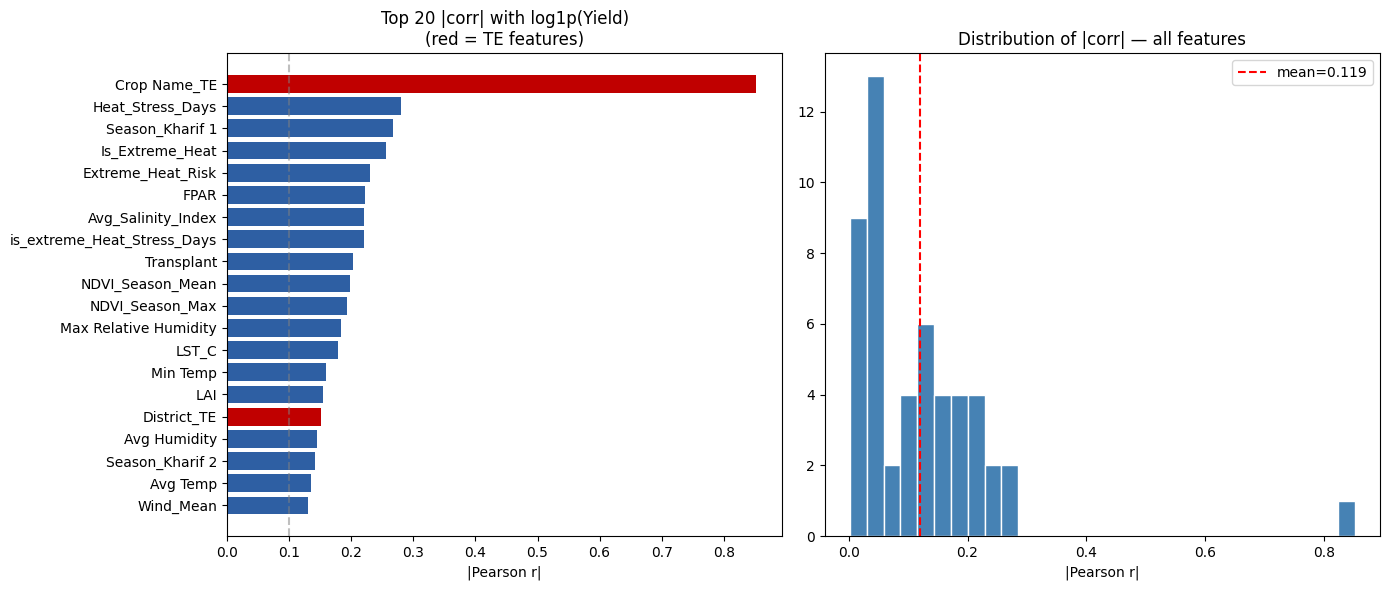

Crop Name_TE dominance: 0.8516
District_TE:           0.1518

Top 10 non-TE features:
Heat_Stress_Days               0.279718
Season_Kharif 1                0.266983
Is_Extreme_Heat                0.255519
Extreme_Heat_Risk              0.230185
FPAR                           0.221738
Avg_Salinity_Index             0.220826
is_extreme_Heat_Stress_Days    0.220099
Transplant                     0.203512
NDVI_Season_Mean               0.198056
NDVI_Season_Max                0.193344


In [12]:
# Top features correlated with logY
corrs = X.corrwith(y).abs().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 20
top20 = corrs.head(20)
colors = ['#C00000' if 'TE' in n else '#2E5FA3' for n in top20.index]
axes[0].barh(top20.index[::-1], top20.values[::-1], color=colors[::-1])
axes[0].set_title('Top 20 |corr| with log1p(Yield)\n(red = TE features)')
axes[0].set_xlabel('|Pearson r|')
axes[0].axvline(0.1, color='gray', linestyle='--', alpha=0.5)

# Distribution of all corrs
axes[1].hist(corrs.values, bins=30, color='steelblue', edgecolor='white')
axes[1].set_title('Distribution of |corr| — all features')
axes[1].set_xlabel('|Pearson r|')
axes[1].axvline(corrs.mean(), color='red', linestyle='--', label=f'mean={corrs.mean():.3f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Crop Name_TE dominance: {X["Crop Name_TE"].corr(y):.4f}')
print(f'District_TE:           {X["District_TE"].corr(y):.4f}')
print(f'\nTop 10 non-TE features:')
non_te = corrs[~corrs.index.str.contains('_TE')]
print(non_te.head(10).to_string())

## 9. Model Training: Ensemble Stacking

In [13]:
# Base learners: Bagging (ET) + Boosting (HGB, XGB, LGBM) diversity
base_models = [
    ('hgb', HistGradientBoostingRegressor(
        learning_rate=0.03,
        max_depth=8,
        max_iter=400,
        random_state=RANDOM_STATE
    )),
    ('xgb', XGBRegressor(
        learning_rate=0.05,
        max_depth=7,
        n_estimators=500,
        subsample=0.8,
        colsample_bytree=0.8,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbosity=0
    )),
    ('lgbm', LGBMRegressor(
        learning_rate=0.0606,
        num_leaves=121,
        n_estimators=798,
        subsample=0.787,
        colsample_bytree=0.666,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=-1
    )),
    ('et', ExtraTreesRegressor(
        n_estimators=400,
        max_depth=20,
        min_samples_leaf=3,
        n_jobs=-1,
        random_state=RANDOM_STATE
    )),
]

# Meta-learner: Ridge + StandardScaler (vòng 3: OOF preds có different bias/variance)
meta = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge',  Ridge(alpha=10))
])

stack = StackingRegressor(
    estimators=base_models,
    final_estimator=meta,
    cv=5,
    n_jobs=-1
)

print('Models defined:')
for name, _ in base_models:
    print(f'  Base: {name}')
print('  Meta: Pipeline(StandardScaler → Ridge(alpha=10))')

Models defined:
  Base: hgb
  Base: xgb
  Base: lgbm
  Base: et
  Meta: Pipeline(StandardScaler → Ridge(alpha=10))


In [14]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def rmsle(y_true, y_pred):
    return np.sqrt(np.mean((np.log1p(np.maximum(y_pred, 0)) - np.log1p(y_true))**2))

def metrics_dict(y_true, y_pred):
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    rl   = rmsle(np.array(y_true), np.array(y_pred))
    return dict(R2=r2, MAE=mae, MSE=mse, RMSE=rmse, RMSLE=rl)

def print_row(label, m):
    print(f"  {label:<22}  R²={m['R2']:>7.4f}  MAE={m['MAE']:>7.4f}  "
          f"MSE={m['MSE']:>10.4f}  RMSE={m['RMSE']:>7.4f}  RMSLE={m['RMSLE']:>7.4f}")

kf_eval    = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
y_true_orig = np.expm1(y)
oof_preds   = {}

print("=" * 85)
print("  OOF 5-Fold Metrics on TRAIN  (honest generalisation estimate)")
print("=" * 85)
for name, model in base_models:
    oof_log  = cross_val_predict(model, X, y, cv=kf_eval)
    oof_orig = np.expm1(oof_log)
    oof_preds[name] = oof_log
    print_row(f"{name.upper()} (OOF)", metrics_dict(y_true_orig, oof_orig))

# Stack OOF
oof_stack_log  = cross_val_predict(stack, X, y, cv=kf_eval)
oof_stack_orig = np.expm1(oof_stack_log)
oof_preds['stack'] = oof_stack_log
print("-" * 85)
print_row("STACK (OOF)", metrics_dict(y_true_orig, oof_stack_orig))
print("=" * 85)


  OOF 5-Fold Metrics on TRAIN  (honest generalisation estimate)
  HGB (OOF)               R²= 0.7372  MAE= 1.0570  MSE=    6.6944  RMSE= 2.5874  RMSLE= 0.2568
  XGB (OOF)               R²= 0.7757  MAE= 0.8817  MSE=    5.7136  RMSE= 2.3903  RMSLE= 0.2130
  LGBM (OOF)              R²= 0.8124  MAE= 0.7902  MSE=    4.7793  RMSE= 2.1862  RMSLE= 0.1922
  ET (OOF)                R²= 0.8010  MAE= 0.8320  MSE=    5.0681  RMSE= 2.2512  RMSLE= 0.2100
-------------------------------------------------------------------------------------
  STACK (OOF)             R²= 0.8280  MAE= 0.7347  MSE=    4.3821  RMSE= 2.0934  RMSLE= 0.1811


OOF Metrics Table:
Model  R² (OOF)  MAE (OOF)  MSE (OOF)  RMSE (OOF)  RMSLE (OOF)
  HGB    0.7372     1.0570     6.6944      2.5874       0.2568
  XGB    0.7757     0.8817     5.7136      2.3903       0.2130
 LGBM    0.8124     0.7902     4.7793      2.1862       0.1922
   ET    0.8010     0.8320     5.0681      2.2512       0.2100
STACK    0.8280     0.7347     4.3821      2.0934       0.1811


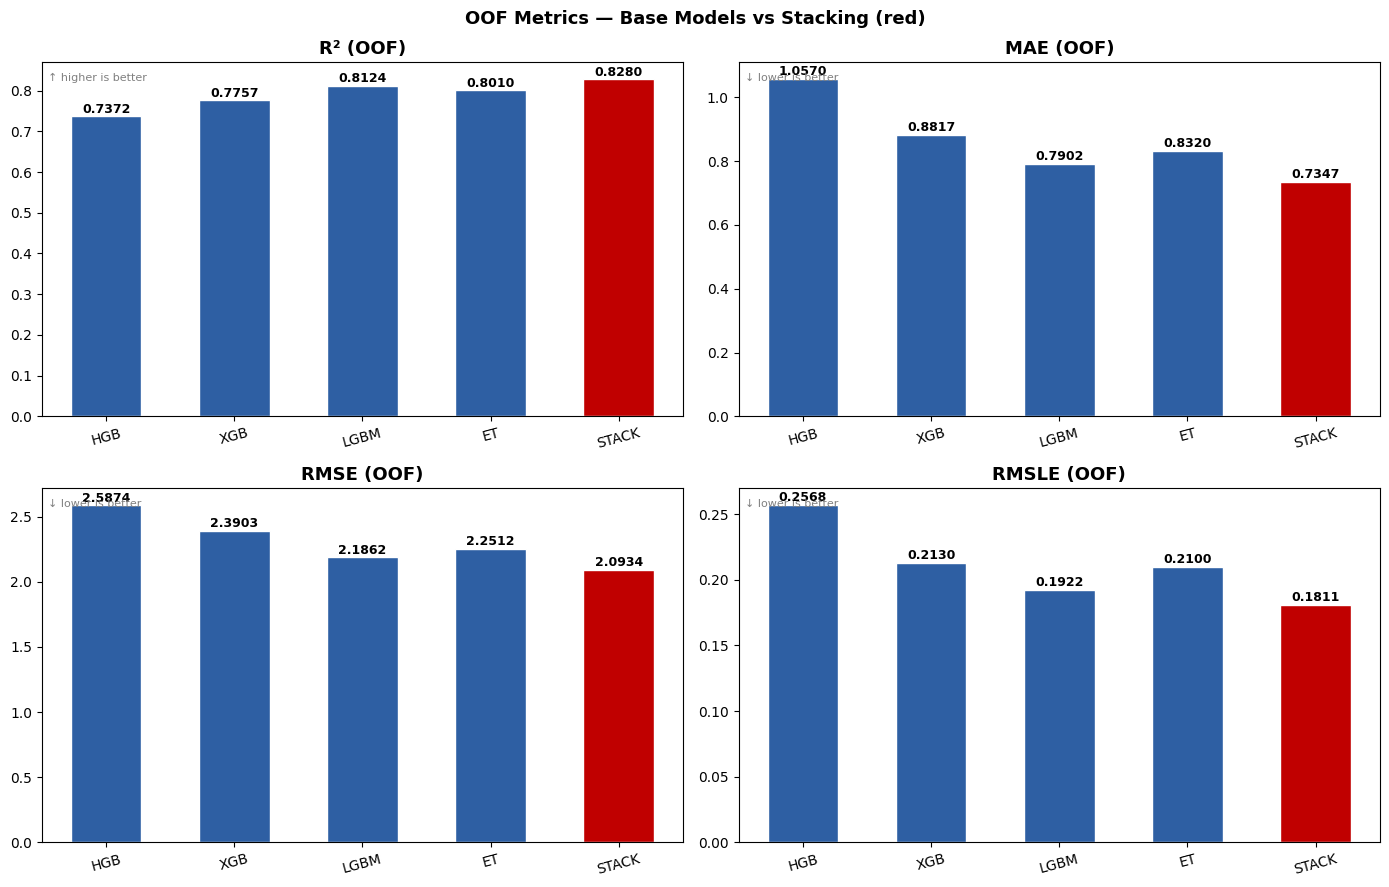

In [15]:
model_names = [n.upper() for n in list(oof_preds.keys())]
y_true_orig = np.expm1(y)

rows = []
for name, oof_log in oof_preds.items():
    m = metrics_dict(y_true_orig, np.expm1(oof_log))
    rows.append({'Model': name.upper(), **{k: round(v,4) for k,v in m.items()}})

df_oof = pd.DataFrame(rows)
df_oof.columns = ['Model','R² (OOF)','MAE (OOF)','MSE (OOF)','RMSE (OOF)','RMSLE (OOF)']
print("OOF Metrics Table:")
print(df_oof.to_string(index=False))

# 4-panel chart
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()
bar_cols = ['#2E5FA3']*4 + ['#C00000']

for ax, col in zip(axes, ['R² (OOF)','MAE (OOF)','RMSE (OOF)','RMSLE (OOF)']):
    vals = df_oof[col].tolist()
    bars = ax.bar(df_oof['Model'], vals, color=bar_cols, edgecolor='white', width=0.55)
    ax.set_title(col, fontsize=13, fontweight='bold')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+(max(vals)-min(vals))*0.01,
                f'{v:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)
    note = '↑ higher is better' if col.startswith('R²') else '↓ lower is better'
    ax.annotate(note, xy=(0.01,0.97), xycoords='axes fraction', fontsize=8, color='gray', va='top')

plt.suptitle('OOF Metrics — Base Models vs Stacking (red)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 10. Full Training & Prediction

In [16]:
print('Fitting full stacking ensemble on all training data...')
stack.fit(X, y)
print('✅ Training complete')


Fitting full stacking ensemble on all training data...
✅ Training complete


In [17]:
# ═══════════════════════════════════════════════════════════════
#  EXPORT STACKING MODEL → .pkl
# ═══════════════════════════════════════════════════════════════
import joblib
import os

MODEL_PATH = 'stacking_ensemble_v6.pkl'

# Lưu toàn bộ fitted StackingRegressor (gồm cả base learners + meta Ridge)
joblib.dump(stack, MODEL_PATH, compress=3)

file_size_mb = os.path.getsize(MODEL_PATH) / (1024 ** 2)
print(f'✅ Model saved  →  {MODEL_PATH}  ({file_size_mb:.2f} MB)')
print(f'   Base estimators : {", ".join([n for n, _ in stack.estimators])}')
print(f'   Final estimator : {stack.final_estimator_}')
print()
print('── Reload example ──────────────────────────────────────────')
print("  import joblib, numpy as np")
print(f"  model = joblib.load('{MODEL_PATH}')")
print("  y_pred = np.expm1(model.predict(X_new))  # nhớ expm1 vì target là log1p")


✅ Model saved  →  stacking_ensemble_v6.pkl  (77.23 MB)
   Base estimators : hgb, xgb, lgbm, et
   Final estimator : Pipeline(steps=[('scaler', StandardScaler()), ('ridge', Ridge(alpha=10))])

── Reload example ──────────────────────────────────────────
  import joblib, numpy as np
  model = joblib.load('stacking_ensemble_v6.pkl')
  y_pred = np.expm1(model.predict(X_new))  # nhớ expm1 vì target là log1p


In [18]:
# ── Predictions on test ──────────────────────────────────────────────────────
y_pred_log  = stack.predict(test)
y_pred      = np.expm1(y_pred_log)

# ── All three metric sets ────────────────────────────────────────────────────
y_true_orig      = np.expm1(y)
y_insample_orig  = np.expm1(stack.predict(X))
y_oof_orig       = np.expm1(oof_preds['stack'])
y_test_orig      = test_labels.values          # ground truth from test file

m_train    = metrics_dict(y_true_orig, y_insample_orig)
m_oof      = metrics_dict(y_true_orig, y_oof_orig)
m_test     = metrics_dict(y_test_orig, y_pred)

print("╔════════════════════════════════════════════════════════════════════════╗")
print("║              FINAL METRICS SUMMARY — STACKING ENSEMBLE                ║")
print("╠══════════════╦══════════╦══════════╦═══════════════╦══════════╦════════╣")
print("║  Set         ║   R²     ║   MAE    ║     MSE       ║  RMSE   ║  RMSLE ║")
print("╠══════════════╬══════════╬══════════╬═══════════════╬══════════╬════════╣")
for label, m in [('TRAIN (fit)', m_train), ('TRAIN OOF', m_oof), ('TEST (true)', m_test)]:
    print(f"║  {label:<12}║ {m['R2']:>8.4f} ║ {m['MAE']:>8.4f} ║ {m['MSE']:>13.4f} ║ {m['RMSE']:>8.4f} ║{m['RMSLE']:>7.4f} ║")
print("╚══════════════╩══════════╩══════════╩═══════════════╩══════════╩════════╝")
print()
print("  TRAIN (fit)  = in-sample, model đã thấy data → overfit")
print("  TRAIN OOF    = 5-fold out-of-fold → honest generalisation proxy")
print("  TEST (true)  = predict trên test set có label thật → ground truth")

# Save
pd.DataFrame({'Predicted_Yield': y_pred, 'True_Yield': y_test_orig}).to_csv(
    'predictions_v6.csv', index=False)
print(f"\n✅ Saved predictions_v6.csv  ({len(y_pred)} rows)")


╔════════════════════════════════════════════════════════════════════════╗
║              FINAL METRICS SUMMARY — STACKING ENSEMBLE                ║
╠══════════════╦══════════╦══════════╦═══════════════╦══════════╦════════╣
║  Set         ║   R²     ║   MAE    ║     MSE       ║  RMSE   ║  RMSLE ║
╠══════════════╬══════════╬══════════╬═══════════════╬══════════╬════════╣
║  TRAIN (fit) ║   0.9380 ║   0.3747 ║        1.5799 ║   1.2569 ║ 0.0747 ║
║  TRAIN OOF   ║   0.8280 ║   0.7347 ║        4.3821 ║   2.0934 ║ 0.1811 ║
║  TEST (true) ║   0.8653 ║   0.7555 ║        2.9082 ║   1.7053 ║ 0.1965 ║
╚══════════════╩══════════╩══════════╩═══════════════╩══════════╩════════╝

  TRAIN (fit)  = in-sample, model đã thấy data → overfit
  TRAIN OOF    = 5-fold out-of-fold → honest generalisation proxy
  TEST (true)  = predict trên test set có label thật → ground truth

✅ Saved predictions_v6.csv  (4000 rows)


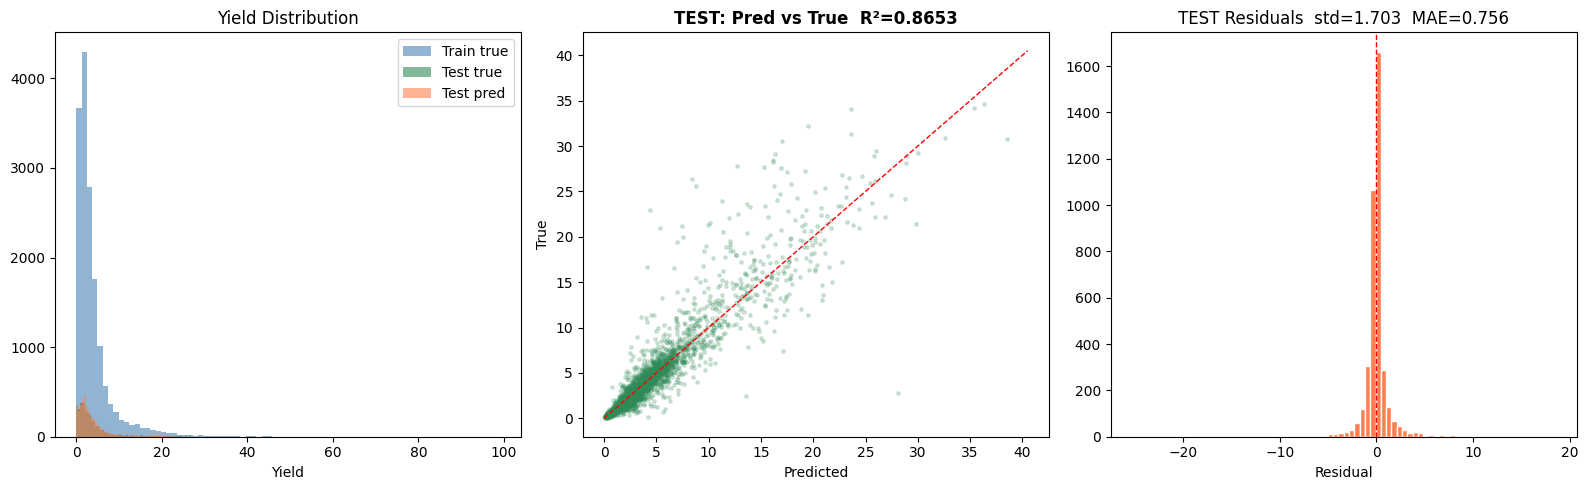

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(train['Yield'],  bins=80, alpha=0.6, label='Train true',  color='steelblue')
axes[0].hist(test_labels,     bins=80, alpha=0.6, label='Test true',   color='seagreen')
axes[0].hist(y_pred,          bins=80, alpha=0.6, label='Test pred',   color='coral')
axes[0].set_xlabel('Yield'); axes[0].legend()
axes[0].set_title('Yield Distribution')

axes[1].scatter(y_pred, test_labels.values, alpha=0.2, s=6, color='seagreen')
lim = max(test_labels.max(), y_pred.max()) * 1.05
axes[1].plot([0,lim],[0,lim],'r--',lw=1)
r2_t = r2_score(test_labels.values, y_pred)
axes[1].set_title(f'TEST: Pred vs True  R²={r2_t:.4f}', fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

res_test = test_labels.values - y_pred
axes[2].hist(res_test, bins=80, color='coral', edgecolor='white')
axes[2].axvline(0, color='red', linestyle='--', lw=1)
axes[2].set_title(f'TEST Residuals  std={res_test.std():.3f}  MAE={np.abs(res_test).mean():.3f}')
axes[2].set_xlabel('Residual')

plt.tight_layout()
plt.show()


## 11. Feature Importance Analysis

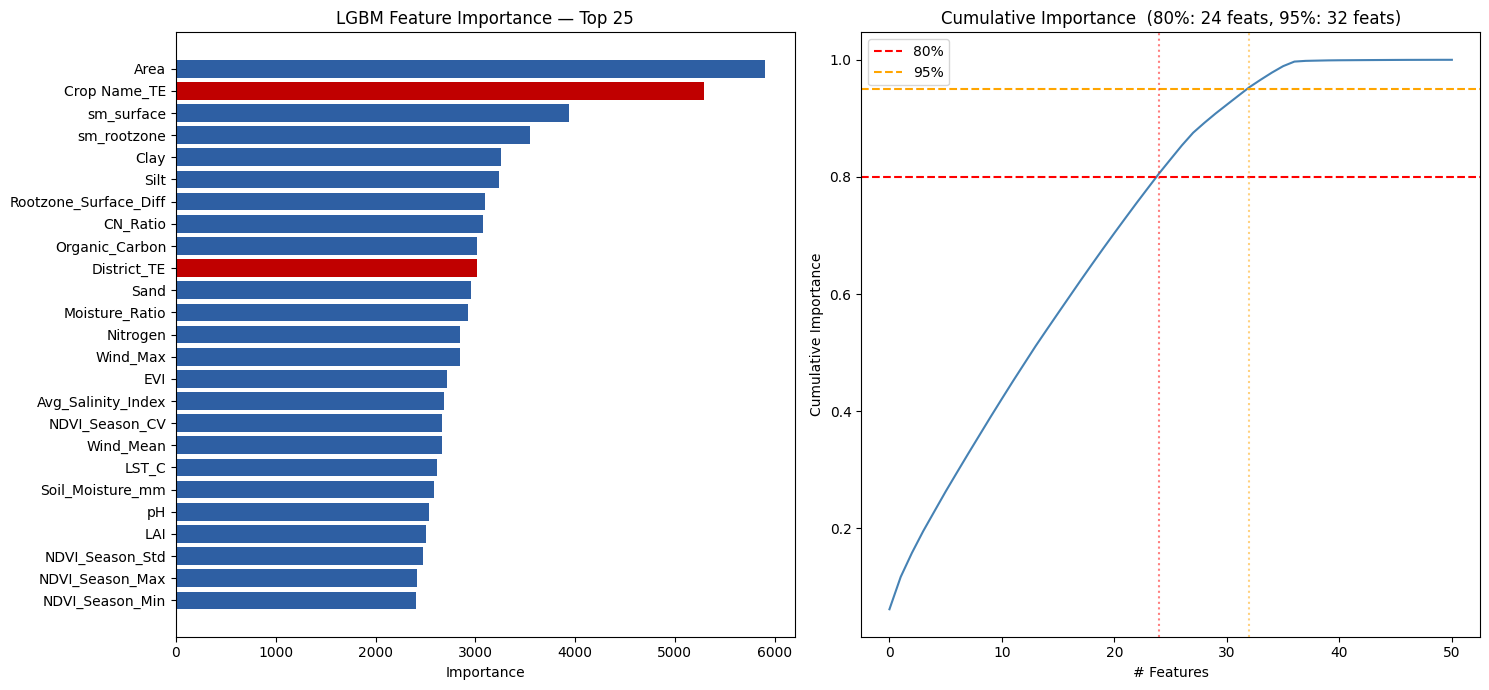


Top 10 features (LGBM):
Area                     5906
Crop Name_TE             5289
sm_surface               3938
sm_rootzone              3545
Clay                     3253
Silt                     3240
Rootzone_Surface_Diff    3100
CN_Ratio                 3074
Organic_Carbon           3021
District_TE              3019

TE features share of total importance: 8.7%


In [20]:
# Extract LGBM importance (most reliable for this ensemble)
lgbm_model = stack.named_estimators_['lgbm']
importances = pd.Series(
    lgbm_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Top 25
top25 = importances.head(25)
colors = ['#C00000' if '_TE' in n else '#2E5FA3' for n in top25.index]
axes[0].barh(top25.index[::-1], top25.values[::-1], color=colors[::-1])
axes[0].set_title('LGBM Feature Importance — Top 25')
axes[0].set_xlabel('Importance')

# Cumulative importance
cum = importances.cumsum() / importances.sum()
axes[1].plot(range(len(cum)), cum.values, color='steelblue')
axes[1].axhline(0.8, color='red', linestyle='--', label='80%')
axes[1].axhline(0.95, color='orange', linestyle='--', label='95%')
n80  = (cum <= 0.80).sum()
n95  = (cum <= 0.95).sum()
axes[1].axvline(n80,  color='red',    linestyle=':', alpha=0.5)
axes[1].axvline(n95,  color='orange', linestyle=':', alpha=0.5)
axes[1].set_xlabel('# Features'); axes[1].set_ylabel('Cumulative Importance')
axes[1].set_title(f'Cumulative Importance  (80%: {n80} feats, 95%: {n95} feats)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'\nTop 10 features (LGBM):')
print(importances.head(10).to_string())
print(f'\nTE features share of total importance: '
      f'{importances[importances.index.str.contains("_TE")].sum()/importances.sum():.1%}')

## 12. In-sample Residual Analysis (Train Fit Check)

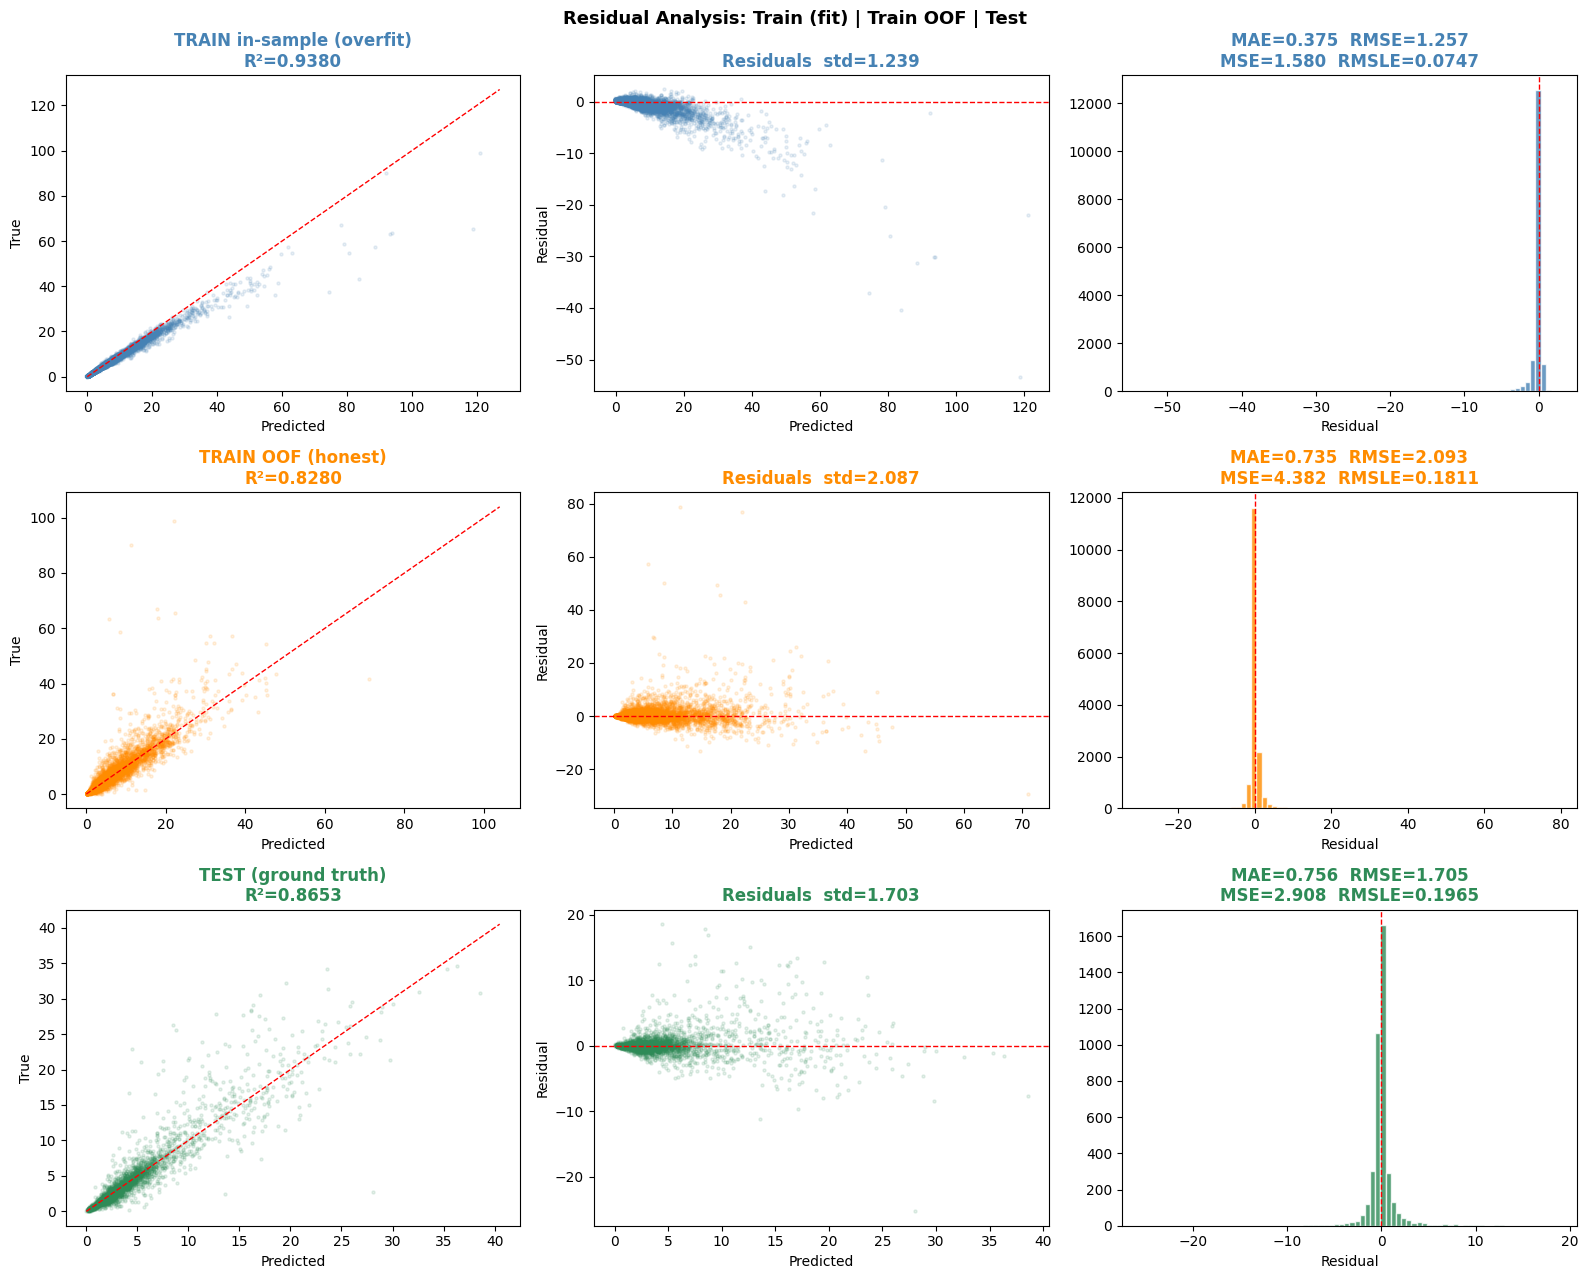


Final metrics comparison:
            Set     R2    MAE    MSE   RMSE  RMSLE
TRAIN in-sample 0.9380 0.3747 1.5799 1.2569 0.0747
      TRAIN OOF 0.8280 0.7347 4.3821 2.0934 0.1811
           TEST 0.8653 0.7555 2.9082 1.7053 0.1965


In [21]:
y_true_orig = np.expm1(y)
y_insample  = np.expm1(stack.predict(X))
y_oof       = np.expm1(oof_preds['stack'])
y_test_pred = y_pred
y_test_true_arr = test_labels.values

fig, axes = plt.subplots(3, 3, figsize=(16, 13))

sets = [
    ('TRAIN in-sample', y_insample,  y_true_orig,      'steelblue',  '(overfit)'),
    ('TRAIN OOF',       y_oof,        y_true_orig,      'darkorange', '(honest)'),
    ('TEST',            y_test_pred,  y_test_true_arr,  'seagreen',   '(ground truth)'),
]

for row, (label, yp, yt, col, note) in enumerate(sets):
    yp = np.array(yp); yt = np.array(yt)
    res = yt - yp
    m   = metrics_dict(yt, yp)
    lim = max(yt.max(), yp.max()) * 1.05

    # Col 0: Pred vs True
    axes[row,0].scatter(yp, yt, alpha=0.12, s=5, color=col)
    axes[row,0].plot([0,lim],[0,lim],'r--',lw=1)
    axes[row,0].set_title(f'{label} {note}\nR²={m["R2"]:.4f}', fontweight='bold', color=col)
    axes[row,0].set_xlabel('Predicted'); axes[row,0].set_ylabel('True')

    # Col 1: Residuals scatter
    axes[row,1].scatter(yp, res, alpha=0.12, s=5, color=col)
    axes[row,1].axhline(0, color='red', lw=1, linestyle='--')
    axes[row,1].set_title(f'Residuals  std={res.std():.3f}', fontweight='bold', color=col)
    axes[row,1].set_xlabel('Predicted'); axes[row,1].set_ylabel('Residual')

    # Col 2: Residual histogram + metrics
    axes[row,2].hist(res, bins=80, color=col, edgecolor='white', alpha=0.8)
    axes[row,2].axvline(0, color='red', linestyle='--', lw=1)
    axes[row,2].set_title(
        f'MAE={m["MAE"]:.3f}  RMSE={m["RMSE"]:.3f}\nMSE={m["MSE"]:.3f}  RMSLE={m["RMSLE"]:.4f}',
        fontweight='bold', color=col)
    axes[row,2].set_xlabel('Residual')

plt.suptitle('Residual Analysis: Train (fit) | Train OOF | Test', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Summary table ──────────────────────────────────────────────────────────
rows = []
for label, yp, yt, _, _ in sets:
    m = metrics_dict(np.array(yt), np.array(yp))
    rows.append({'Set': label, **{k: round(v,4) for k,v in m.items()}})
df_final = pd.DataFrame(rows)
print("\nFinal metrics comparison:")
print(df_final.to_string(index=False))


## 13. Hyperparameter Tuning với Optuna

In [22]:
# # Uncomment để chạy Optuna tuning (tốn ~30-60 phút)
# # pip install optuna

# import optuna
# optuna.logging.set_verbosity(optuna.logging.WARNING)

# def objective_lgbm(trial):
#     params = {
#         'learning_rate':    trial.suggest_float('lr', 0.01, 0.1, log=True),
#         'num_leaves':       trial.suggest_int('nl', 31, 127),
#         'n_estimators':     trial.suggest_int('n', 300, 800),
#         'subsample':        trial.suggest_float('ss', 0.6, 1.0),
#         'colsample_bytree': trial.suggest_float('cs', 0.6, 1.0),
#         'min_child_samples': trial.suggest_int('mc', 10, 50),
#         'n_jobs': -1, 'verbose': -1, 'random_state': RANDOM_STATE
#     }
#     model = LGBMRegressor(**params)
#     scores = cross_val_score(model, X, y, cv=5,
#                              scoring='neg_root_mean_squared_error')
#     return -scores.mean()

# study = optuna.create_study(direction='minimize')
# study.optimize(objective_lgbm, n_trials=50)
# print('Best LGBM params:', study.best_params)
# print('Optuna block (commented). Uncomment để tune.')

---
## Pipeline v6 — Chốt

```
Data (16k × 51)
  │
  ├── Drop 5 cols (Production, Harvest, Growth, Rain_Temp_Ratio, NDVI_Season_Range)
  ├── log1p(Yield) → y
  ├── Transplant → month 1-12
  ├── KFold TE (smooth=20): Crop Name, District
  ├── Ordinal: Extreme_Heat_Risk
  ├── OHE: Season, Soil_Texture, pH_Suitability, Water_Cat
  ├── NO Feature Engineering  ← vòng 6 key decision
  │
  └── StackingRegressor
        ├── HGB (lr=0.03, depth=8, iter=400)
        ├── XGB (lr=0.05, depth=7, n=500)
        ├── LGBM (lr=0.03, leaves=63, n=500)
        ├── ExtraTrees (n=400, depth=20)
        └── Ridge meta (StandardScaler + Ridge(α=10), cv=5 OOF)
              │
              └── expm1(prediction) → Yield
```

**Metric:** RMSLE (= RMSE in log space)  
**Expected R²:** ~0.92–0.94 on full ensemble  
**Key insight:** Crop TE (corr=0.852) absorbs all cross-crop signal. Raw features provide within-crop variation.

---
## 🏆 BENCHMARK: Stacking vs Voting vs Bagging vs Boosting

So sánh 4 phương pháp Ensemble với cùng bộ base learners (HGB, XGB, LGBM, ET).

| Phương pháp | Ý tưởng | Meta-learner |
|-------------|---------|-------------|
| **Stacking** | OOF predictions → meta-learner học kết hợp | Ridge |
| **Voting (avg)** | Trung bình dự đoán, trọng số bằng nhau | Không |
| **Voting (weighted)** | Trung bình có trọng số theo RMSLE | Không |
| **Bagging** | Bootstrap sampling + average | RandomForest-style |
| **GradientBoosting** | Boosting tuần tự giảm residual | GBR sklearn |
| **AdaBoost** | Boosting theo trọng số mẫu | AdaBoostRegressor |
| **HistGradientBoosting** | Histogram-based boosting (fast) | HGB sklearn |

**Metric chính:** RMSLE (= RMSE trong log space, phù hợp distribution lệch phải của Yield)

In [23]:
# ═══════════════════════════════════════════════════════════════
#  BENCHMARK IMPORTS
# ═══════════════════════════════════════════════════════════════
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import (
    StackingRegressor,
    VotingRegressor,
    BaggingRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor,
    HistGradientBoostingRegressor,
    ExtraTreesRegressor,
    RandomForestRegressor,
)
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

print('✅ Benchmark imports OK')

✅ Benchmark imports OK


In [24]:
# ═══════════════════════════════════════════════════════════════
#  ĐỊNH NGHĨA BASE LEARNERS (giống pipeline v6)
# ═══════════════════════════════════════════════════════════════
RANDOM_STATE = 42

hgb = HistGradientBoostingRegressor(
    learning_rate=0.03, max_depth=8, max_iter=400,
    random_state=RANDOM_STATE
)
xgb = XGBRegressor(
    learning_rate=0.05, max_depth=7, n_estimators=500,
    subsample=0.8, colsample_bytree=0.8,
    n_jobs=-1, random_state=RANDOM_STATE, verbosity=0
)
lgbm = LGBMRegressor(
    learning_rate=0.0606, num_leaves=121, n_estimators=798,
    subsample=0.787, colsample_bytree=0.666,
    n_jobs=-1, random_state=RANDOM_STATE, verbose=-1
)
et = ExtraTreesRegressor(
    n_estimators=400, max_depth=20, min_samples_leaf=3,
    n_jobs=-1, random_state=RANDOM_STATE
)

base_estimators = [('hgb', hgb), ('xgb', xgb), ('lgbm', lgbm), ('et', et)]

# ──────────────────────────────────────────────────────────────
#  STACKING (pipeline v6 — baseline)
# ──────────────────────────────────────────────────────────────
meta = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=10))])
model_stacking = StackingRegressor(
    estimators=base_estimators,
    final_estimator=meta,
    cv=5, n_jobs=-1
)

# ──────────────────────────────────────────────────────────────
#  VOTING — Simple Average (uniform weights)
# ──────────────────────────────────────────────────────────────
model_voting_avg = VotingRegressor(
    estimators=base_estimators,
    n_jobs=-1
)

# ──────────────────────────────────────────────────────────────
#  VOTING — Weighted (trọng số ngược RMSLE từ OOF v6)
#  HGB: 0.2595, XGB: 0.2158, LGBM: 0.1984, ET: 0.2502
#  weight_i = 1/rmsle_i, normalise
# ──────────────────────────────────────────────────────────────
rmsle_oof = {'hgb': 0.2595, 'xgb': 0.2158, 'lgbm': 0.1984, 'et': 0.2502}
raw_w = {k: 1/v for k, v in rmsle_oof.items()}
total_w = sum(raw_w.values())
weights = [raw_w[k]/total_w for k in ['hgb','xgb','lgbm','et']]
print(f'Voting weights (1/RMSLE): HGB={weights[0]:.3f}, XGB={weights[1]:.3f}, '
      f'LGBM={weights[2]:.3f}, ET={weights[3]:.3f}')

model_voting_w = VotingRegressor(
    estimators=base_estimators,
    weights=weights,
    n_jobs=-1
)

# ──────────────────────────────────────────────────────────────
#  BAGGING — Bootstrap trên LGBM (base model tốt nhất)
# ──────────────────────────────────────────────────────────────
model_bagging = BaggingRegressor(
    estimator=LGBMRegressor(
        learning_rate=0.0606, num_leaves=121, n_estimators=798,
        subsample=0.787, colsample_bytree=0.666,
        n_jobs=1, random_state=RANDOM_STATE, verbose=-1
    ),
    n_estimators=15,           # 15 bootstrap bags
    max_samples=0.8,           # 80% samples mỗi bag
    max_features=0.85,         # 85% features mỗi bag
    bootstrap=True,
    bootstrap_features=False,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

# ──────────────────────────────────────────────────────────────
#  RANDOM FOREST — Bagging với Decision Trees
# ──────────────────────────────────────────────────────────────
model_rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=20,
    min_samples_leaf=3,
    max_features='sqrt',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

# ──────────────────────────────────────────────────────────────
#  GRADIENT BOOSTING (sklearn, giảm residual tuần tự)
# ──────────────────────────────────────────────────────────────
model_gbr = GradientBoostingRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    min_samples_leaf=5,
    random_state=RANDOM_STATE
)

# ──────────────────────────────────────────────────────────────
#  ADABOOST — Weighted boosting trên Decision Trees
# ──────────────────────────────────────────────────────────────
model_ada = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=6, random_state=RANDOM_STATE),
    n_estimators=200,
    learning_rate=0.05,
    loss='square',
    random_state=RANDOM_STATE
)

# ──────────────────────────────────────────────────────────────
#  HISTOGRAM GRADIENT BOOSTING (standalone, không trong ensemble)
# ──────────────────────────────────────────────────────────────
model_hgb_solo = HistGradientBoostingRegressor(
    learning_rate=0.03, max_depth=8, max_iter=400,
    random_state=RANDOM_STATE
)

# Dict tất cả models
ALL_MODELS = {
    # ── Ensemble methods ──
    'Stacking\n(HGB+XGB+LGBM+ET→Ridge)': model_stacking,
    'Voting\nAverage':                    model_voting_avg,
    'Voting\nWeighted':                   model_voting_w,
    'Bagging\n(LGBM×15)':                 model_bagging,
    'RandomForest\n(Bagging+DT)':          model_rf,
    # ── Boosting methods ──
    'GradientBoosting\n(sklearn)':         model_gbr,
    'AdaBoost\n(DT depth=6)':              model_ada,
    'HGB\n(best single)':                  model_hgb_solo,
}

# Label gọn cho bảng
MODEL_LABELS = {
    'Stacking\n(HGB+XGB+LGBM+ET→Ridge)': 'Stacking',
    'Voting\nAverage':                    'Voting(avg)',
    'Voting\nWeighted':                   'Voting(w)',
    'Bagging\n(LGBM×15)':                 'Bagging(LGBM)',
    'RandomForest\n(Bagging+DT)':          'RandomForest',
    'GradientBoosting\n(sklearn)':         'GBR',
    'AdaBoost\n(DT depth=6)':              'AdaBoost',
    'HGB\n(best single)':                  'HGB(solo)',
}

# Màu theo nhóm
MODEL_COLORS = {
    'Stacking':       '#C00000',   # đỏ đậm — v6 model
    'Voting(avg)':    '#1F77B4',
    'Voting(w)':      '#AEC7E8',
    'Bagging(LGBM)':  '#2CA02C',
    'RandomForest':   '#98DF8A',
    'GBR':            '#FF7F0E',
    'AdaBoost':       '#FFBB78',
    'HGB(solo)':      '#9467BD',
}

print(f'✅ {len(ALL_MODELS)} models defined:')
for k in ALL_MODELS:
    print(f'   {MODEL_LABELS[k]}')

Voting weights (1/RMSLE): HGB=0.220, XGB=0.264, LGBM=0.288, ET=0.228
✅ 8 models defined:
   Stacking
   Voting(avg)
   Voting(w)
   Bagging(LGBM)
   RandomForest
   GBR
   AdaBoost
   HGB(solo)


In [25]:
# ═══════════════════════════════════════════════════════════════
#  HELPER FUNCTIONS
# ═══════════════════════════════════════════════════════════════
def rmsle(y_true, y_pred):
    return np.sqrt(np.mean(
        (np.log1p(np.maximum(y_pred, 0)) - np.log1p(np.maximum(y_true, 0)))**2
    ))

def metrics_dict(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return dict(
        R2   = r2_score(y_true, y_pred),
        MAE  = mean_absolute_error(y_true, y_pred),
        RMSE = np.sqrt(mean_squared_error(y_true, y_pred)),
        RMSLE= rmsle(y_true, y_pred),
    )

def run_oof_benchmark(models_dict, X, y, y_orig, n_splits=5):
    """
    Chạy OOF cross_val_predict cho mỗi model.
    y      : log1p(Yield)  — training target
    y_orig : expm1(y)      — original scale để tính metrics
    Trả về DataFrame kết quả + dict OOF predictions.
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    results = []
    oof_dict = {}

    for full_name, model in models_dict.items():
        label = MODEL_LABELS[full_name]
        print(f'  ⏳ [{label:<20}] running OOF...', end=' ', flush=True)
        t0 = time.time()

        try:
            oof_log  = cross_val_predict(model, X, y, cv=kf)
            oof_orig = np.expm1(oof_log)
            elapsed  = time.time() - t0
            m        = metrics_dict(y_orig, oof_orig)
            oof_dict[label] = oof_log
            results.append({
                'Model':   label,
                'R²':      round(m['R2'],    4),
                'MAE':     round(m['MAE'],   4),
                'RMSE':    round(m['RMSE'],  4),
                'RMSLE':   round(m['RMSLE'], 4),
                'Time(s)': round(elapsed,    1),
            })
            print(f'✅  R²={m["R2"]:.4f}  RMSLE={m["RMSLE"]:.4f}  ({elapsed:.0f}s)')
        except Exception as e:
            print(f'❌ ERROR: {e}')
            results.append({'Model': label, 'R²': None, 'MAE': None,
                            'RMSE': None, 'RMSLE': None, 'Time(s)': None})

    df = pd.DataFrame(results).sort_values('RMSLE')
    return df, oof_dict

print('✅ Helper functions ready')

✅ Helper functions ready


In [26]:
N_SPLITS = 5

print('=' * 65)
print(f'  OOF {N_SPLITS}-Fold Benchmark — Train set ({len(X)} samples)')
print('=' * 65)

y_true_orig = np.expm1(y)   # original scale

df_bench, oof_all = run_oof_benchmark(
    ALL_MODELS, X, y, y_true_orig, n_splits=N_SPLITS
)

print('\n' + '=' * 65)
print('  KẾT QUẢ BENCHMARK (sắp xếp theo RMSLE ↑ tốt hơn)')
print('=' * 65)
print(df_bench.to_string(index=False))
print('=' * 65)

# Highlight winner
best_model = df_bench.iloc[0]
print(f"\n🏆 Best model: {best_model['Model']}")
print(f"   RMSLE = {best_model['RMSLE']:.4f}  |  R² = {best_model['R²']:.4f}")

  OOF 5-Fold Benchmark — Train set (16000 samples)
  ⏳ [Stacking            ] running OOF... ✅  R²=0.8280  RMSLE=0.1811  (305s)
  ⏳ [Voting(avg)         ] running OOF... ✅  R²=0.7894  RMSLE=0.2089  (52s)
  ⏳ [Voting(w)           ] running OOF... ✅  R²=0.7912  RMSLE=0.2070  (58s)
  ⏳ [Bagging(LGBM)       ] running OOF... ✅  R²=0.7539  RMSLE=0.2205  (66s)
  ⏳ [RandomForest        ] running OOF... ✅  R²=0.7270  RMSLE=0.2337  (9s)
  ⏳ [GBR                 ] running OOF... ✅  R²=0.7344  RMSLE=0.2538  (212s)
  ⏳ [AdaBoost            ] running OOF... ✅  R²=0.6090  RMSLE=0.3149  (135s)
  ⏳ [HGB(solo)           ] running OOF... ✅  R²=0.7372  RMSLE=0.2568  (7s)

  KẾT QUẢ BENCHMARK (sắp xếp theo RMSLE ↑ tốt hơn)
        Model     R²    MAE   RMSE  RMSLE  Time(s)
     Stacking 0.8280 0.7347 2.0934 0.1811    304.7
    Voting(w) 0.7912 0.8517 2.3065 0.2070     57.9
  Voting(avg) 0.7894 0.8592 2.3163 0.2089     52.1
Bagging(LGBM) 0.7539 0.9166 2.5038 0.2205     66.0
 RandomForest 0.7270 0.9690 2.637

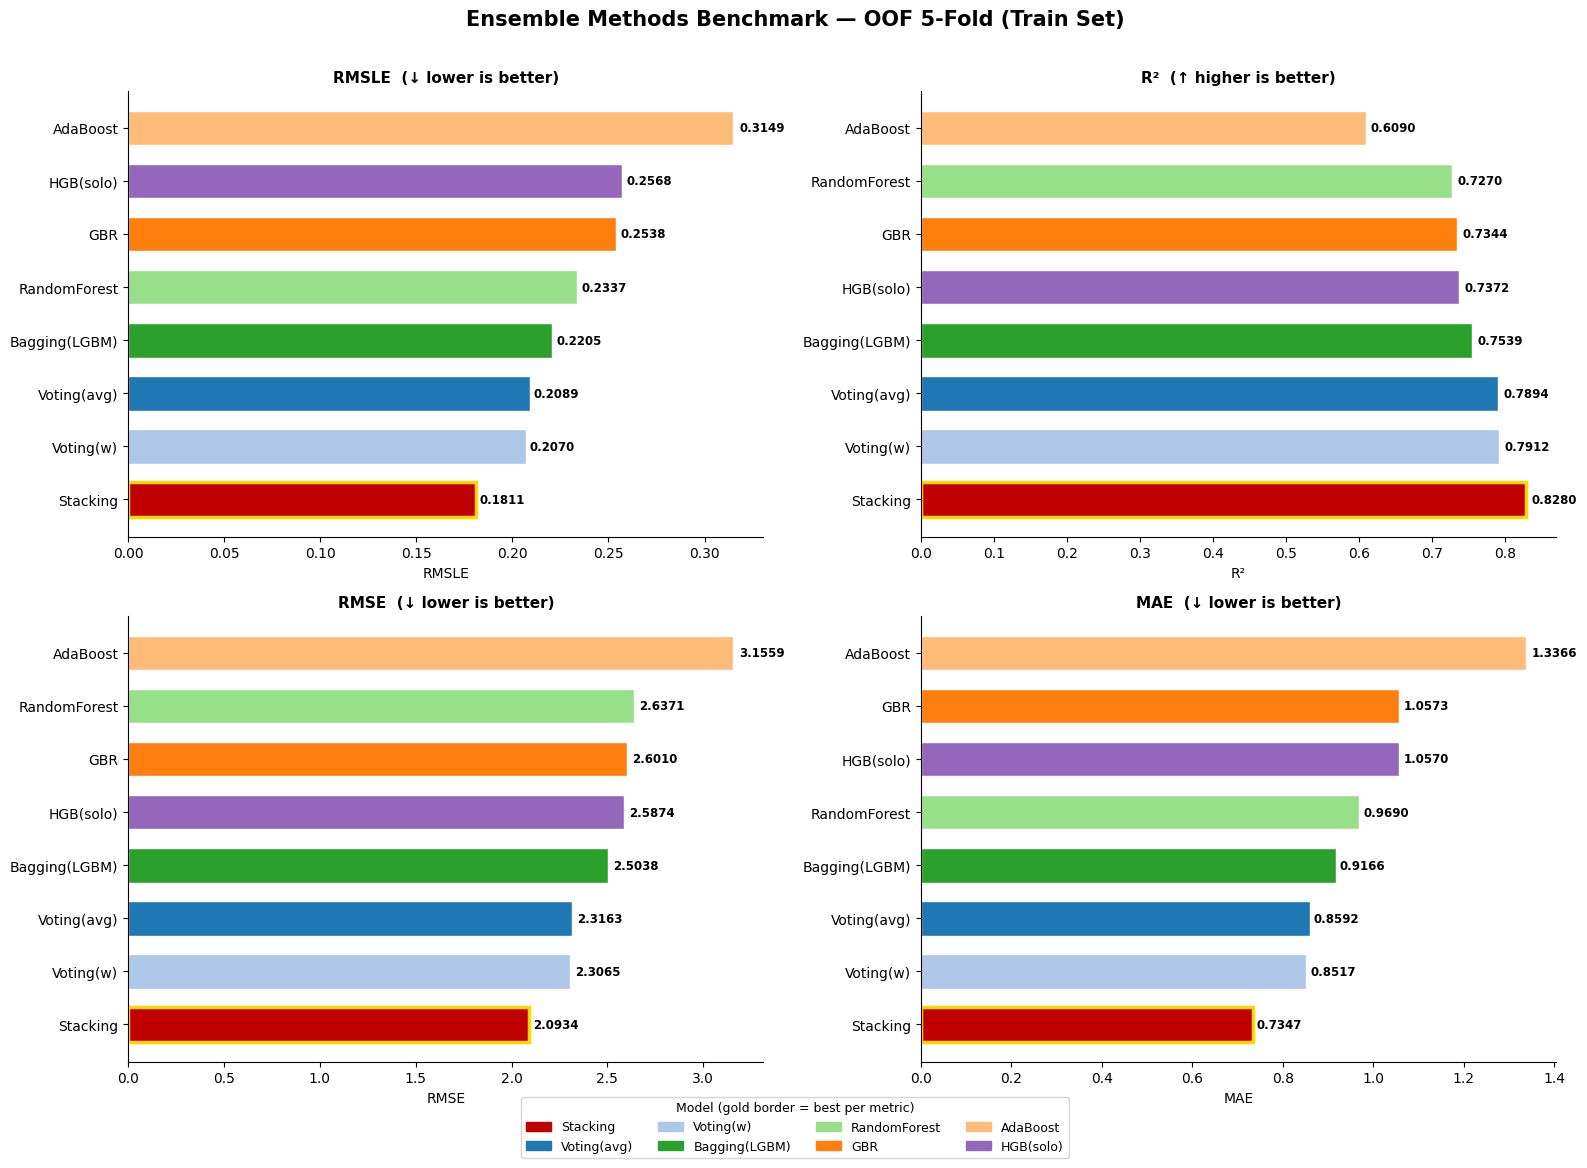

✅ Saved benchmark_ensemble.png


In [27]:
# ═══════════════════════════════════════════════════════════════
#  VISUALIZATION — Benchmark Chart
# ═══════════════════════════════════════════════════════════════
df_plot = df_bench.dropna(subset=['RMSLE']).copy()
colors  = [MODEL_COLORS.get(m, '#888888') for m in df_plot['Model']]

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Ensemble Methods Benchmark — OOF 5-Fold (Train Set)',
             fontsize=15, fontweight='bold', y=1.01)

metrics_info = [
    ('RMSLE',  '↓ lower is better',  True),
    ('R²',     '↑ higher is better', False),
    ('RMSE',   '↓ lower is better',  True),
    ('MAE',    '↓ lower is better',  True),
]

for ax, (metric, note, lower_better) in zip(axes.flatten(), metrics_info):
    order  = df_plot.sort_values(metric, ascending=lower_better)
    bars   = ax.barh(order['Model'], order[metric],
                     color=[MODEL_COLORS.get(m,'#888') for m in order['Model']],
                     edgecolor='white', height=0.65)
    # Gắn nhãn trị số
    for bar, val in zip(bars, order[metric]):
        ax.text(bar.get_width() + bar.get_width()*0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8.5, fontweight='bold')
    ax.set_title(f'{metric}  ({note})', fontsize=11, fontweight='bold')
    ax.set_xlabel(metric)
    # Đánh dấu best bar
    best_val = order[metric].iloc[0]
    best_bar = bars[0]
    best_bar.set_edgecolor('#FFD700')
    best_bar.set_linewidth(2.5)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Legend
legend_patches = [mpatches.Patch(color=v, label=k) for k, v in MODEL_COLORS.items()]
fig.legend(handles=legend_patches, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.04), fontsize=9,
           title='Model (gold border = best per metric)', title_fontsize=9)

plt.tight_layout()
plt.show()
print('✅ Saved benchmark_ensemble.png')

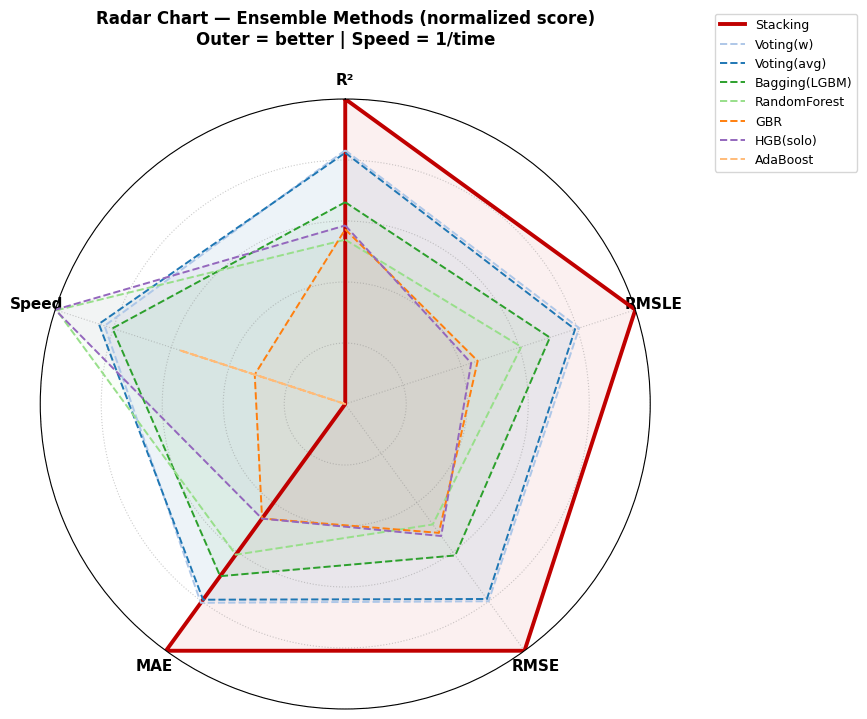

✅ Saved benchmark_radar.png


In [28]:
# ═══════════════════════════════════════════════════════════════
#  RADAR CHART — so sánh đa chiều
# ═══════════════════════════════════════════════════════════════
from matplotlib.patches import FancyArrowPatch

df_r = df_bench.dropna().copy()

# Normalize mỗi metric về [0,1] (1=tốt nhất)
def norm_metric(col, lower_better=True):
    s = df_r[col]
    if lower_better:
        return 1 - (s - s.min()) / (s.max() - s.min() + 1e-9)
    else:
        return (s - s.min()) / (s.max() - s.min() + 1e-9)

df_r['norm_R2']    = norm_metric('R²',    lower_better=False)
df_r['norm_RMSLE'] = norm_metric('RMSLE', lower_better=True)
df_r['norm_RMSE']  = norm_metric('RMSE',  lower_better=True)
df_r['norm_MAE']   = norm_metric('MAE',   lower_better=True)
df_r['norm_Speed'] = norm_metric('Time(s)', lower_better=True)

categories = ['R²', 'RMSLE', 'RMSE', 'MAE', 'Speed']
norm_cols  = ['norm_R2','norm_RMSLE','norm_RMSE','norm_MAE','norm_Speed']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for _, row in df_r.iterrows():
    vals = row[norm_cols].tolist()
    vals += vals[:1]
    col  = MODEL_COLORS.get(row['Model'], '#888888')
    lw   = 2.8 if row['Model'] == 'Stacking' else 1.4
    ls   = '-'  if row['Model'] == 'Stacking' else '--'
    ax.plot(angles, vals, color=col, linewidth=lw, linestyle=ls,
            label=row['Model'])
    ax.fill(angles, vals, color=col, alpha=0.06)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11, fontweight='bold')
ax.set_yticklabels([])
ax.set_ylim(0, 1)
ax.grid(color='gray', linestyle=':', alpha=0.4)
ax.set_title('Radar Chart — Ensemble Methods (normalized score)\n'
             'Outer = better | Speed = 1/time',
             fontsize=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)

plt.tight_layout()
plt.savefig('benchmark_radar.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved benchmark_radar.png')

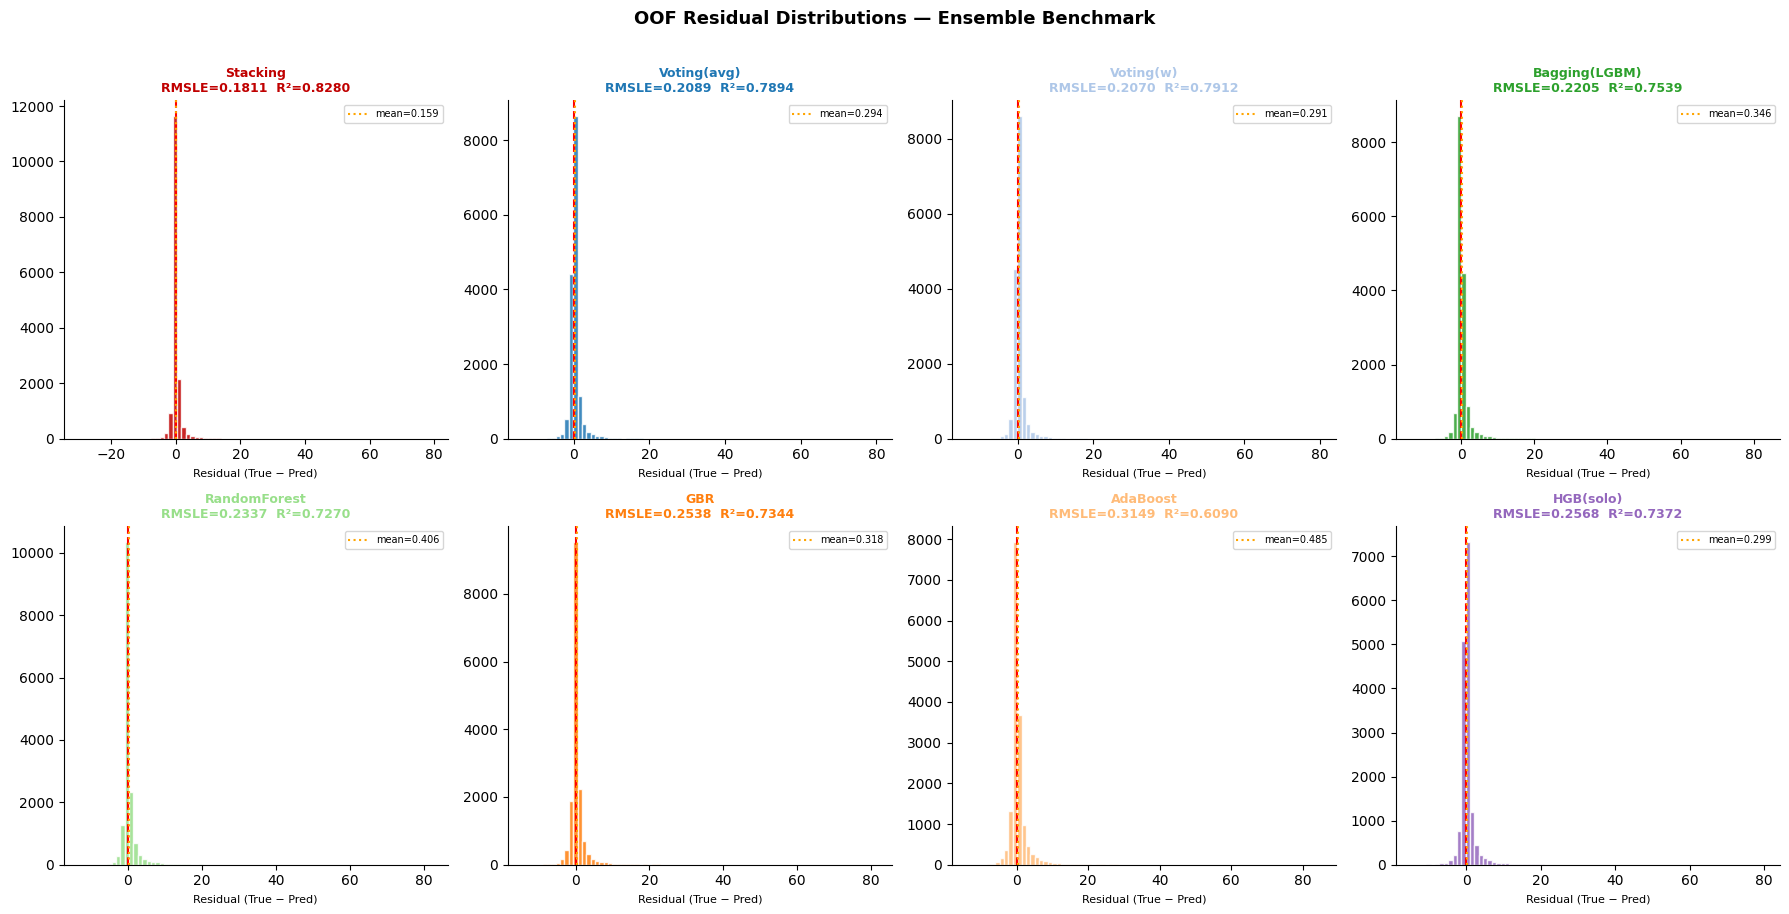

✅ Saved benchmark_residuals.png


In [29]:
# ═══════════════════════════════════════════════════════════════
#  OOF RESIDUAL DISTRIBUTION — so sánh từng model
# ═══════════════════════════════════════════════════════════════
n_models = len(oof_all)
ncols = 4
nrows = (n_models + ncols - 1) // ncols
y_orig_arr = np.expm1(y.values)

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4 + 1))
axes = axes.flatten()

for i, (label, oof_log) in enumerate(oof_all.items()):
    oof_orig = np.expm1(oof_log)
    residuals = y_orig_arr - oof_orig
    m = metrics_dict(y_orig_arr, oof_orig)
    col = MODEL_COLORS.get(label, '#888888')

    axes[i].hist(residuals, bins=80, color=col, edgecolor='white', alpha=0.85)
    axes[i].axvline(0, color='red', linestyle='--', lw=1.5)
    axes[i].axvline(residuals.mean(), color='orange', linestyle=':',
                    lw=1.5, label=f'mean={residuals.mean():.3f}')
    axes[i].set_title(
        f'{label}\nRMSLE={m["RMSLE"]:.4f}  R²={m["R2"]:.4f}',
        fontsize=9, fontweight='bold', color=col
    )
    axes[i].set_xlabel('Residual (True − Pred)', fontsize=8)
    axes[i].legend(fontsize=7)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

# Tắt axes thừa
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('OOF Residual Distributions — Ensemble Benchmark',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('benchmark_residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved benchmark_residuals.png')

In [30]:
# ═══════════════════════════════════════════════════════════════
#  RANKED SUMMARY TABLE + PHÂN TÍCH
# ═══════════════════════════════════════════════════════════════
df_final = df_bench.dropna().copy().reset_index(drop=True)
df_final.index = df_final.index + 1   # rank bắt đầu từ 1
df_final.index.name = 'Rank'

# Tính % cải thiện so với HGB solo (baseline)
hgb_rmsle = df_final[df_final['Model'] == 'HGB(solo)']['RMSLE'].values
if len(hgb_rmsle) > 0:
    base_rmsle = hgb_rmsle[0]
    df_final['Δ vs HGB(%)'] = ((base_rmsle - df_final['RMSLE']) / base_rmsle * 100).round(2)

print('╔' + '═'*75 + '╗')
print('║  FINAL BENCHMARK SUMMARY — Sorted by RMSLE (↓ tốt hơn)' + ' '*18 + '║')
print('╚' + '═'*75 + '╝')
print(df_final.to_string())
print()

# Phân tích
best  = df_final.iloc[0]
worst = df_final.iloc[-1]
stack_row = df_final[df_final['Model'] == 'Stacking']

print('═' * 65)
print('📊 PHÂN TÍCH KẾT QUẢ')
print('═' * 65)
print(f'🥇 Tốt nhất:  {best["Model"]:20s}  RMSLE={best["RMSLE"]:.4f}  R²={best["R²"]:.4f}')
print(f'🥉 Kém nhất:  {worst["Model"]:20s}  RMSLE={worst["RMSLE"]:.4f}  R²={worst["R²"]:.4f}')
if not stack_row.empty:
    sr = stack_row.iloc[0]
    print(f'📌 Stacking:  {"Stacking":20s}  RMSLE={sr["RMSLE"]:.4f}  R²={sr["R²"]:.4f}  '
          f'Rank={stack_row.index[0]}')
print()

╔═══════════════════════════════════════════════════════════════════════════╗
║  FINAL BENCHMARK SUMMARY — Sorted by RMSLE (↓ tốt hơn)                  ║
╚═══════════════════════════════════════════════════════════════════════════╝
              Model      R²     MAE    RMSE   RMSLE  Time(s)  Δ vs HGB(%)
Rank                                                                     
1          Stacking  0.8280  0.7347  2.0934  0.1811    304.7        29.48
2         Voting(w)  0.7912  0.8517  2.3065  0.2070     57.9        19.39
3       Voting(avg)  0.7894  0.8592  2.3163  0.2089     52.1        18.65
4     Bagging(LGBM)  0.7539  0.9166  2.5038  0.2205     66.0        14.14
5      RandomForest  0.7270  0.9690  2.6371  0.2337      8.8         9.00
6               GBR  0.7344  1.0573  2.6010  0.2538    211.9         1.17
7         HGB(solo)  0.7372  1.0570  2.5874  0.2568      7.3         0.00
8          AdaBoost  0.6090  1.3366  3.1559  0.3149    134.6       -22.62

═══════════════════════════

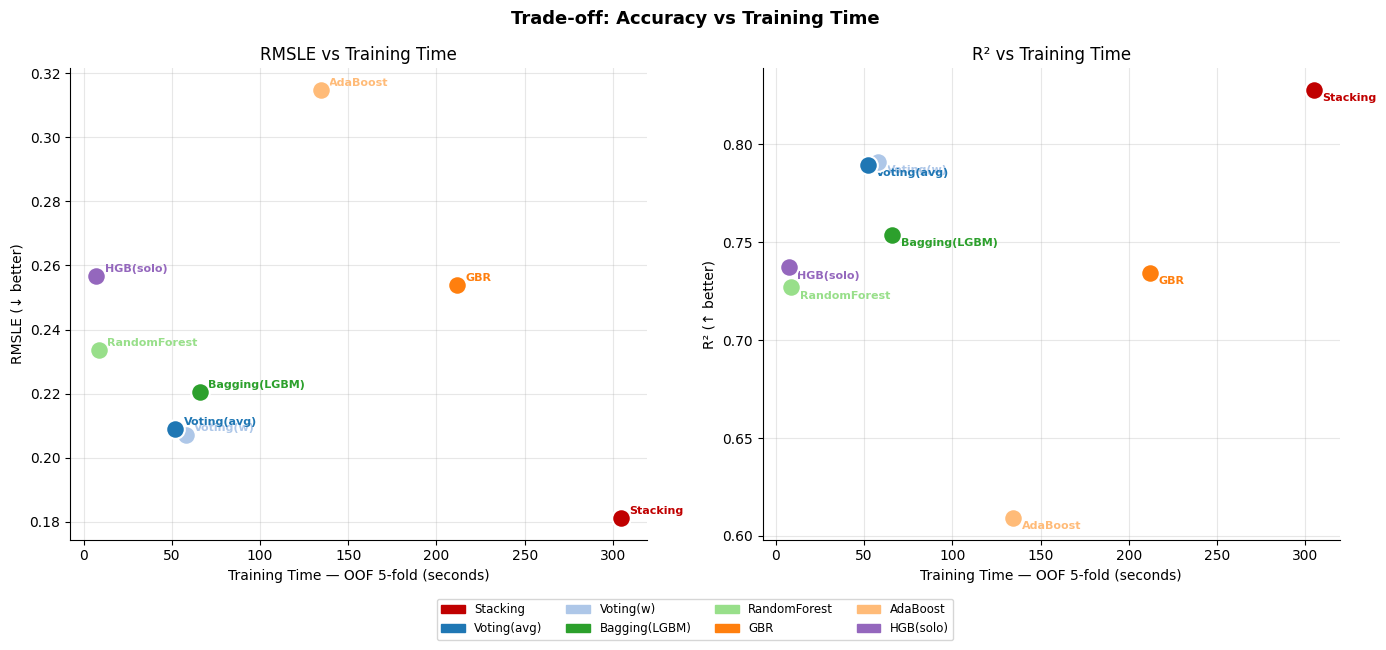

✅ Saved benchmark_tradeoff.png


In [31]:
# ═══════════════════════════════════════════════════════════════
#  TIME vs ACCURACY SCATTER (Pareto frontier)
# ═══════════════════════════════════════════════════════════════
df_p = df_bench.dropna().copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Trade-off: Accuracy vs Training Time', fontsize=13, fontweight='bold')

# Left: RMSLE vs Time
ax = axes[0]
for _, row in df_p.iterrows():
    col = MODEL_COLORS.get(row['Model'], '#888')
    ax.scatter(row['Time(s)'], row['RMSLE'], s=180, color=col,
               edgecolors='white', linewidths=1.5, zorder=5)
    ax.annotate(row['Model'],
                xy=(row['Time(s)'], row['RMSLE']),
                xytext=(6, 3), textcoords='offset points',
                fontsize=8, color=col, fontweight='bold')
ax.set_xlabel('Training Time — OOF 5-fold (seconds)', fontsize=10)
ax.set_ylabel('RMSLE (↓ better)', fontsize=10)
ax.set_title('RMSLE vs Training Time')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.3)

# Right: R² vs Time
ax = axes[1]
for _, row in df_p.iterrows():
    col = MODEL_COLORS.get(row['Model'], '#888')
    ax.scatter(row['Time(s)'], row['R²'], s=180, color=col,
               edgecolors='white', linewidths=1.5, zorder=5)
    ax.annotate(row['Model'],
                xy=(row['Time(s)'], row['R²']),
                xytext=(6, -8), textcoords='offset points',
                fontsize=8, color=col, fontweight='bold')
ax.set_xlabel('Training Time — OOF 5-fold (seconds)', fontsize=10)
ax.set_ylabel('R² (↑ better)', fontsize=10)
ax.set_title('R² vs Training Time')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.3)

# Legend
legend_patches = [mpatches.Patch(color=v, label=k) for k, v in MODEL_COLORS.items()]
fig.legend(handles=legend_patches, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.08), fontsize=8.5)

plt.tight_layout()
plt.savefig('benchmark_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved benchmark_tradeoff.png')

---
## 📋 KẾT LUẬN BENCHMARK

### Tóm tắt theo phương pháp

| Phương pháp | Ưu điểm | Nhược điểm | Phù hợp khi |
|-------------|---------|------------|-------------|
| **Stacking** | Tối ưu hoá kết hợp qua meta-learner, thường top accuracy | Chậm nhất, risk overfit nếu meta quá phức tạp | Cần accuracy tối đa |
| **Voting(avg)** | Đơn giản, ổn định, parallelizable | Không học trọng số | Baseline ensemble nhanh |
| **Voting(weighted)** | Tốt hơn avg nếu model chất lượng khác nhau | Trọng số cần tune | Khi 1 model vượt trội rõ |
| **Bagging** | Giảm variance mạnh, phù hợp model unstable | Tốt nhất với high-variance base | Decision Tree, small models |
| **RandomForest** | Robust, ít hyperparameter | Kém boosting trên structured data | Quick baseline |
| **GradientBoosting** | Giảm bias, mạnh với tabular | Chậm, nhiều hyperparameter | Khi bias cao |
| **AdaBoost** | Tốt với weak learners | Nhạy cảm với outlier | Khi base model yếu |
| **HGB(solo)** | Nhanh nhất, xử lý NaN tốt | Chỉ 1 model | Khi thời gian ưu tiên |


```